# Sales Forecasting: Model Training & Evaluation

### Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import RandomizedSearchCV
import pmdarima as pm
import streamlit as st
import joblib
import json
from datetime import timedelta


### Load and Inspect the Dataset

In [2]:

ts_m = pd.read_csv(r"c:\Users\HP USER\Documents\sales_forecasting_app\data\sf_new_features.csv")

In [3]:
ts_m.head()

,Date,Sales,Year,Month,Quarter,MonthName,Month_sin,Month_cos,Sales_lag_1,Sales_lag_2,Sales_lag_3,Sales_lag_12,Rolling_mean_3,Rolling_std_3,Rolling_mean_6,Pct_change_1,Diff_1,IsHoliday
0,2016-01-31,18066.9576,2016,1,1,January,0.500000,8.660254e-01,68167.0585,77907.6607,31453.3930,14205.707,59176.037400,24497.522165,53341.786417,-0.734961,-50100.1009,1
1,2016-02-29,11951.4110,2016,2,1,February,0.866025,5.000000e-01,18066.9576,68167.0585,77907.6607,4519.892,54713.892267,32108.693498,50722.688850,-0.338493,-6115.5466,1
2,2016-03-31,32339.3184,2016,3,1,March,1.000000,6.123234e-17,11951.4110,18066.9576,68167.0585,55205.797,32728.475700,30842.662672,48195.001267,1.705900,20387.9074,0
3,2016-04-30,34154.4685,2016,4,2,April,0.866025,-5.000000e-01,32339.3184,11951.4110,18066.9576,27906.855,20785.895667,10462.368766,39980.966533,0.056128,1815.1501,0
4,2016-05-31,29959.5305,2016,5,2,May,0.500000,-8.660254e-01,34154.4685,32339.3184,11951.4110,23644.303,26148.399300,12328.404198,40431.145783,-0.122823,-4194.9380,1


In [4]:
ts_m.shape


(36, 18)

In [5]:
ts_m.groupby('IsHoliday')['Sales'].mean()


IsHoliday
0    41038.076167
1    53717.652525
Name: Sales, dtype: float64

In [6]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0 
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [7]:
split_ratio = 0.8
split_idx = int(len(ts_m) * split_ratio)

train = ts_m.iloc[:split_idx]
test = ts_m.iloc[split_idx:]

print(train['Date'].min(), 'to', train['Date'].max())
print(test['Date'].min(), 'to', test['Date'].max())
print(train.shape, test.shape)

2016-01-31 to 2018-04-30
2018-05-31 to 2018-12-31
(28, 18) (8, 18)


Thene features waas splitted into  

In [8]:
feature_cols = [c for c in ts_m.columns if c not in ['Date', 'Sales', 'MonthName']]

print(feature_cols)

['Year', 'Month', 'Quarter', 'Month_sin', 'Month_cos', 'Sales_lag_1', 'Sales_lag_2', 'Sales_lag_3', 'Sales_lag_12', 'Rolling_mean_3', 'Rolling_std_3', 'Rolling_mean_6', 'Pct_change_1', 'Diff_1', 'IsHoliday']


In [9]:
X_train = train[feature_cols]
y_train = train['Sales']
X_test = test[feature_cols]
y_test = test['Sales']

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(28, 15) (28,)
(8, 15) (8,)


### Naive Model


In [10]:


naive_pred = test['Sales_lag_1']  # "predict last period's value"
mae_naive = mean_absolute_error(y_test, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_test, naive_pred))
mape_naive = mape(y_test, naive_pred)
print('Naive MAPE:', mape_naive)
print('Naive MAE:', mae_naive, 'RMSE:', rmse_naive,'Naive MAPE:', mape_naive)

Naive MAPE: 22.351100627307623
Naive MAE: 17680.5965125 RMSE: 22081.72681394189 Naive MAPE: 22.351100627307623


### Linear Reression Model

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
mape_lr = mape(y_test, lr_pred)
print('Linear Regression MAE:', mae_lr, 'RMSE:', rmse_lr, 'LR MAPE:', mape_lr)

Linear Regression MAE: 8.094502845779061e-11 RMSE: 1.2106874268133643e-10 LR MAPE: 1.001471423860369e-13


### Random Forest Model

In [12]:


rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mape_rf = mape(y_test, rf_pred)
print('Random Forest MAE:', mae_rf, 'RMSE:', rmse_rf, 'MAPE:', mape_rf)

Random Forest MAE: 12549.990370727457 RMSE: 15912.455254144717 MAPE: 16.602619541610586


### XGBoost Model

In [13]:

xgb = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_xgb = mape(y_test, xgb_pred)
print('XGBoost MAE:', mae_xgb, 'RMSE:', rmse_xgb,'XGBoost MAPE:', mape_xgb )

XGBoost MAE: 11209.907475 RMSE: 15126.54227704208 XGBoost MAPE: 14.336838929643058


### Prophet Model

In [14]:

prophet_train = train[['Date','Sales']].rename(columns={'Date':'ds','Sales':'y'})
prophet_test = test[['Date','Sales']].rename(columns={'Date':'ds','Sales':'y'})

m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
m.fit(prophet_train)

future = prophet_test[['ds']]
forecast = m.predict(future)

mae_prophet = mean_absolute_error(prophet_test['y'], forecast['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'], forecast['yhat']))
mape_prophet = mape(prophet_test['y'], forecast['yhat'])

print('Prophet MAE:', mae_prophet, 'RMSE:', rmse_prophet,'Prophet MAPE:', mape_prophet )

12:09:35 - cmdstanpy - INFO - Chain [1] start processing
12:09:37 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 23095.658423216424 RMSE: 27067.542123518335 Prophet MAPE: 35.767462890132784


In [15]:

train_series = train.set_index('Date')['Sales']
test_series = test.set_index('Date')['Sales']

arima_model = ARIMA(train_series, order=(2,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test_series))
arima_pred.index = test_series.index

mae_arima = mean_absolute_error(test_series, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test_series, arima_pred))
mape_arima = mape(test_series, arima_pred)
print('ARIMA MAE:', mae_arima, 'RMSE:', rmse_arima, 'MAPE:', mape_arima)

c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


ARIMA MAE: 24641.499636132357 RMSE: 33408.702528507296 MAPE: 28.198434748120583


In [16]:


sarima_model = SARIMAX(
    train_series,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),   # m=7: Weekly Seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(test_series))
sarima_pred.index = test_series.index

mae_sarima = mean_absolute_error(test_series, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test_series, sarima_pred))
mape_sarima = mape(test_series, sarima_pred)
print('SARIMA MAE:', mae_sarima, 'RMSE:', rmse_sarima, 'MAPE:', mape_sarima)

c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


SARIMA MAE: 15126.146118854007 RMSE: 20098.398524782166 MAPE: 20.182132226343143


In [17]:
results = pd.DataFrame({
    'Model': ['Naive', 'Linear Regression', 'Random Forest', 'XGBoost', 'Prophet', 'ARIMA', 'SARIMA'],
    'MAE': [mae_naive, mae_lr, mae_rf, mae_xgb, mae_prophet, mae_arima, mae_sarima],
    'RMSE': [rmse_naive, rmse_lr, rmse_rf, rmse_xgb, rmse_prophet, rmse_arima, rmse_sarima],
    'MAPE': [mape_naive, mape_lr, mape_rf, mape_xgb, mape_prophet, mape_arima, mape_sarima]
})
print(results.sort_values('MAE'))

               Model           MAE          RMSE          MAPE
1  Linear Regression  8.094503e-11  1.210687e-10  1.001471e-13
3            XGBoost  1.120991e+04  1.512654e+04  1.433684e+01
2      Random Forest  1.254999e+04  1.591246e+04  1.660262e+01
6             SARIMA  1.512615e+04  2.009840e+04  2.018213e+01
0              Naive  1.768060e+04  2.208173e+04  2.235110e+01
4            Prophet  2.309566e+04  2.706754e+04  3.576746e+01
5              ARIMA  2.464150e+04  3.340870e+04  2.819843e+01


### Prediction intervals

Residual-based interval, using the existing XGBoost model and test predictions.

In [18]:
residuals = y_test - xgb_pred
resid_std = residuals.std()

lower_90 = xgb_pred - 1.645 * resid_std
upper_90 = xgb_pred + 1.645 * resid_std

interval_df = pd.DataFrame({
    'Date': test['Date'].values,
    'Actual': y_test.values,
    'Predicted': xgb_pred,
    'Lower_90': lower_90,
    'Upper_90': upper_90
})
print(interval_df.head())

coverage = ((interval_df['Actual'] >= interval_df['Lower_90']) &
            (interval_df['Actual'] <= interval_df['Upper_90'])).mean()
print(f'90% interval coverage: {coverage:.1%}')

         Date      Actual     Predicted      Lower_90      Upper_90
0  2018-05-31  43825.9822  40490.429688  21006.888104  59973.971271
1  2018-06-30  48190.7277  41737.847656  22254.306073  61221.389240
2  2018-07-31  44825.1040  38362.777344  18879.235760  57846.318927
3  2018-08-31  62837.8480  54941.492188  35457.950604  74425.033771
4  2018-09-30  86152.8880  75293.804688  55810.263104  94777.346271
90% interval coverage: 87.5%


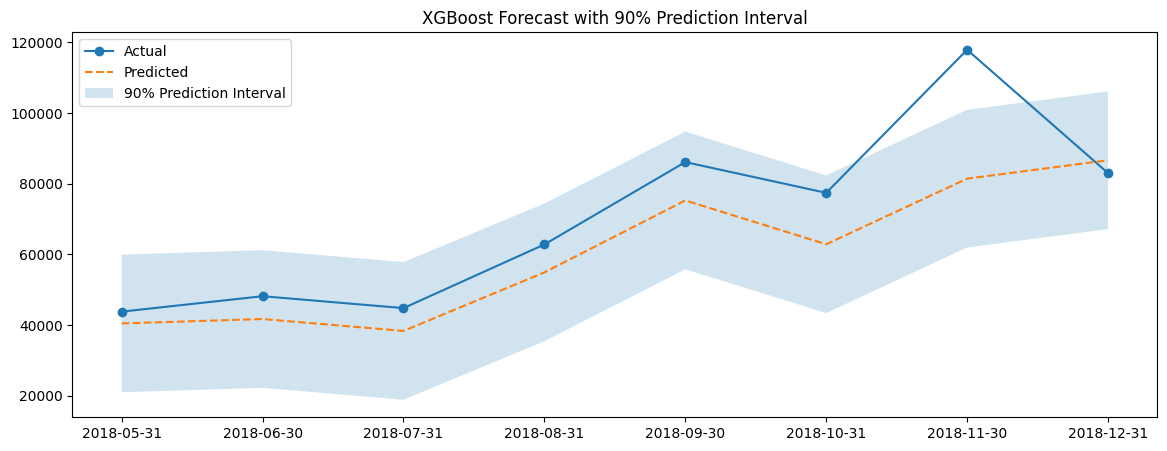

In [19]:
plt.figure(figsize=(14,5))
plt.plot(interval_df['Date'], interval_df['Actual'], label='Actual', marker='o')
plt.plot(interval_df['Date'], interval_df['Predicted'], label='Predicted', linestyle='--')
plt.fill_between(interval_df['Date'], interval_df['Lower_90'], interval_df['Upper_90'],
                  alpha=0.2, label='90% Prediction Interval')
plt.legend()
plt.title('XGBoost Forecast with 90% Prediction Interval')
plt.show()

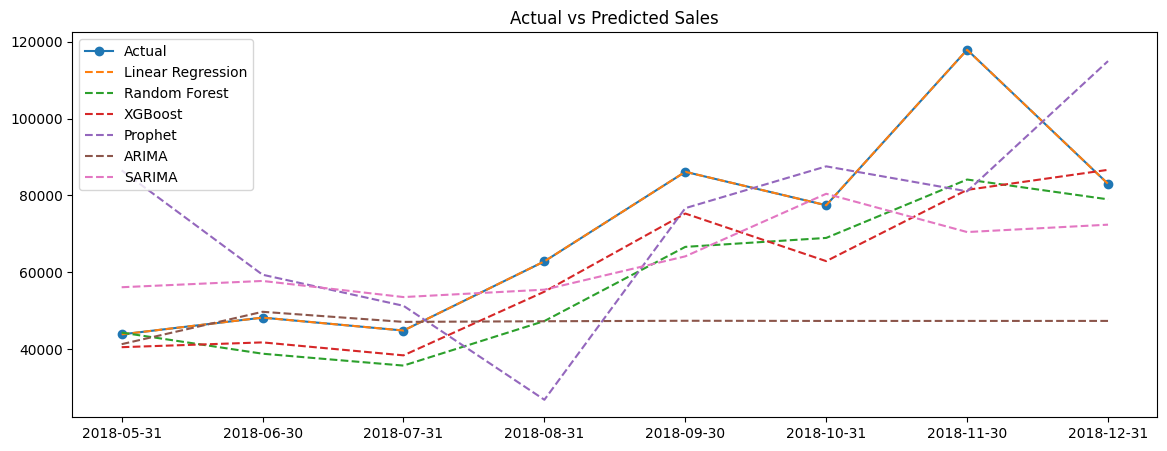

In [20]:
plt.figure(figsize=(14,5))
plt.plot(test['Date'], y_test, label='Actual', marker='o')
plt.plot(test['Date'], lr_pred, label='Linear Regression', linestyle='--')
plt.plot(test['Date'], rf_pred, label ='Random Forest', linestyle='--')
plt.plot(test['Date'], xgb_pred, label='XGBoost', linestyle='--')
plt.plot(test['Date'], forecast['yhat'].values, label='Prophet', linestyle='--')
plt.plot(test['Date'], arima_pred.values, label='ARIMA', linestyle='--')
plt.plot(test['Date'], sarima_pred.values, label='SARIMA', linestyle='--')
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.show()

In [21]:


tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    cv_scores.append(mean_absolute_error(y_val, pred))

print('CV MAE scores:', cv_scores)
print('Mean CV MAE:', np.mean(cv_scores))

CV MAE scores: [30071.132925, 7514.832421874999, 13319.365809375002, 18467.327557812503, 9816.85433671875]
Mean CV MAE: 15837.902610156252


In [22]:
tscv = TimeSeriesSplit(n_splits=4)  # 4 folds — keeps each validation window a reasonable size given only ~48 rows

fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(ts_m), start=1):
    train_fold = ts_m.iloc[train_idx]
    val_fold = ts_m.iloc[val_idx]

    X_tr, y_tr = train_fold[feature_cols], train_fold['Sales']
    X_val, y_val = val_fold[feature_cols], val_fold['Sales']

    tr_series = train_fold.set_index('Date')['Sales']
    val_series = val_fold.set_index('Date')['Sales']

    row = {'Fold': fold, 'Train_size': len(train_fold), 'Val_size': len(val_fold)}

    # --- Naive ---
    naive_pred = np.full(len(val_fold), tr_series.iloc[-1])
    row['Naive_MAE'] = mean_absolute_error(y_val, naive_pred)
    row['Naive_RMSE'] = np.sqrt(mean_squared_error(y_val, naive_pred))
    row['Naive_MAPE'] = mape(y_val, naive_pred)

    # --- Linear Regression ---
    lr = LinearRegression().fit(X_tr, y_tr)
    lr_pred = lr.predict(X_val)
    row['LR_MAE'] = mean_absolute_error(y_val, lr_pred)
    row['LR_RMSE'] = np.sqrt(mean_squared_error(y_val, lr_pred))
    row['LR_MAPE'] = mape(y_val, lr_pred)

    # --- Random Forest ---
    rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42).fit(X_tr, y_tr)
    rf_pred = rf.predict(X_val)
    row['RF_MAE'] = mean_absolute_error(y_val, rf_pred)
    row['RF_RMSE'] = np.sqrt(mean_squared_error(y_val, rf_pred))
    row['RF_MAPE'] = mape(y_val, rf_pred)

    # --- XGBoost ---
    xgb = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42).fit(X_tr, y_tr)
    xgb_pred = xgb.predict(X_val)
    row['XGB_MAE'] = mean_absolute_error(y_val, xgb_pred)
    row['XGB_RMSE'] = np.sqrt(mean_squared_error(y_val, xgb_pred))
    row['XGB_MAPE'] = mape(y_val, xgb_pred)

    # --- Prophet ---
    p_train = train_fold[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
    p_val = val_fold[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
    m.fit(p_train)
    forecast = m.predict(p_val[['ds']])
    row['Prophet_MAE'] = mean_absolute_error(p_val['y'], forecast['yhat'])
    row['Prophet_RMSE'] = np.sqrt(mean_squared_error(p_val['y'], forecast['yhat']))
    row['Prophet_MAPE'] = mape(p_val['y'], forecast['yhat'])

    # --- ARIMA ---
    try:
        arima_fit = ARIMA(tr_series, order=(2,1,2)).fit()
        arima_pred = arima_fit.forecast(steps=len(val_series))
        row['ARIMA_MAE'] = mean_absolute_error(val_series, arima_pred)
        row['ARIMA_RMSE'] = np.sqrt(mean_squared_error(val_series, arima_pred))
        row['ARIMA_MAPE'] = mape(val_series, arima_pred)
    except Exception as e:
        row['ARIMA_MAE'] = row['ARIMA_RMSE'] = row['ARIMA_MAPE'] = np.nan

    # --- SARIMA (m=12, monthly yearly seasonality) ---
    try:
        sarima_fit = SARIMAX(tr_series, order=(1,1,1), seasonal_order=(1,0,1,12),
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        sarima_pred = sarima_fit.forecast(steps=len(val_series))
        row['SARIMA_MAE'] = mean_absolute_error(val_series, sarima_pred)
        row['SARIMA_RMSE'] = np.sqrt(mean_squared_error(val_series, sarima_pred))
        row['SARIMA_MAPE'] = mape(val_series, sarima_pred)
    except Exception as e:
        row['SARIMA_MAE'] = row['SARIMA_RMSE'] = row['SARIMA_MAPE'] = np.nan

    fold_results.append(row)

cv_df = pd.DataFrame(fold_results)
cv_df

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
12:09:42 - cmdstanpy - INFO - Chain [1] start processing
12:09:43 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWar

,Fold,Train_size,Val_size,Naive_MAE,Naive_RMSE,Naive_MAPE,LR_MAE,LR_RMSE,LR_MAPE,RF_MAE,...,XGB_MAPE,Prophet_MAE,Prophet_RMSE,Prophet_MAPE,ARIMA_MAE,ARIMA_RMSE,ARIMA_MAPE,SARIMA_MAE,SARIMA_RMSE,SARIMA_MAPE
0,1,8,7,22105.754286,24950.575808,49.845008,2.501005e-03,2.977376e-03,5.608432e-06,22471.844788,...,37.686186,233667.781984,306243.814191,496.290078,22696.126237,25935.700751,49.341714,21973.352319,24434.947829,51.465693
1,2,15,7,12761.593514,13643.891342,30.285000,6.600333e-11,7.730781e-11,1.412742e-13,12012.300683,...,30.936040,41355.871719,49164.434186,84.774812,17259.242682,23292.032898,31.596912,11821.225146,13951.938502,23.812163
2,3,22,7,21703.705614,24917.419112,57.624021,1.507163e-11,1.787535e-11,3.157723e-14,13179.188290,...,23.811253,31925.887985,38780.390329,60.442148,21153.337346,25310.283002,48.447893,12787.146069,14886.183027,32.971223
3,4,29,7,30520.195329,38420.819878,34.877266,1.767018e-11,2.039494e-11,2.593631e-14,14766.091636,...,15.107331,21434.458152,25079.168858,29.183483,27471.210153,35119.045719,31.212060,29250.158828,37420.441599,34.556136


In [23]:
summary = pd.DataFrame({
    'Model': ['Naive', 'Linear Regression','Random Forest', 'XGBoost', 'Prophet', 'ARIMA', 'SARIMA'],
    'Mean_MAE': [cv_df['Naive_MAE'].mean(), cv_df['LR_MAE'].mean(), cv_df['RF_MAE'].mean(), cv_df['XGB_MAE'].mean(),
                 cv_df['Prophet_MAE'].mean(), cv_df['ARIMA_MAE'].mean(), cv_df['SARIMA_MAE'].mean()],
    'Std_MAE': [cv_df['Naive_MAE'].std(), cv_df['LR_MAE'].std(), cv_df['RF_MAE'].std(), cv_df['XGB_MAE'].std(),
                cv_df['Prophet_MAE'].std(), cv_df['ARIMA_MAE'].std(), cv_df['SARIMA_MAE'].std()],
    'Mean_MAPE': [cv_df['Naive_MAPE'].mean(), cv_df['LR_MAPE'].mean(),cv_df['RF_MAPE'].mean(), cv_df['XGB_MAPE'].mean(),
                  cv_df['Prophet_MAPE'].mean(), cv_df['ARIMA_MAPE'].mean(), cv_df['SARIMA_MAPE'].mean()]
})
print(summary.sort_values('Mean_MAE'))

               Model      Mean_MAE        Std_MAE   Mean_MAPE
1  Linear Regression      0.000625       0.001251    0.000001
2      Random Forest  15607.356349    4713.433045   25.362423
3            XGBoost  15846.696123    4264.892290   26.885203
6             SARIMA  18957.970590    8246.895911   35.701304
0              Naive  21772.812186    7253.376224   43.157824
5              ARIMA  22144.979104    4223.989982   40.149644
4            Prophet  82095.999960  101374.924488  167.672630


1. XGBoost: hyperparameter tuning with TimeSeriesSplit

In [24]:

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=40,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print('Best params:', xgb_search.best_params_)
print('Best CV MAE:', -xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_
xgb_tuned_pred = best_xgb.predict(X_test)

mae_xgb_tuned = mean_absolute_error(y_test, xgb_tuned_pred)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
mape_xgb_tuned = mape(y_test, xgb_tuned_pred)
print('Tuned XGBoost — MAE:', mae_xgb_tuned, 'RMSE:', rmse_xgb_tuned, 'MAPE:', mape_xgb_tuned)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV MAE: 15386.944803046877
Tuned XGBoost — MAE: 10790.0784609375 RMSE: 14825.213553203266 MAPE: 13.65120560251984


In [25]:
"""
Run this once (from your modelling notebook, after the tuned XGBoost cell)
to produce the artifacts app.py needs:

  - sales_forecast_xgb_model.pkl
  - feature_cols.json
  - model_meta.json           <- previously failed: `residual_std` was
                                  never assigned before being saved
  - historical_sales_for_inference.csv

Assumes `ts_m`, `feature_cols`, `y_test`, and `xgb_pred_tuned` already
exist from the modelling notebook.
"""

import json

import joblib
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

# --- residual_std, computed from pooled cross-validation residuals ---
# The previous version computed residual_std from y_test - xgb_pred_tuned,
# i.e. from the 8-row holdout test set alone. A standard deviation from
# only 8 points is highly unstable and easily inflated by one or two
# larger errors — this was producing prediction intervals that looked far
# wider than the point forecast, because the interval width (±1.645 *
# residual_std) was being driven by a noisy 8-point estimate.
#
# Fix: pool out-of-fold residuals across every fold of the SAME
# TimeSeriesSplit cross-validation already used to evaluate XGBoost during
# modelling (see the CV section of the modelling notebook). This uses far
# more residuals (all CV test folds combined, ~28+ points instead of 8),
# giving a much more stable and representative estimate of typical error.
tscv = TimeSeriesSplit(n_splits=4)
oof_residuals = []
for train_idx, test_idx in tscv.split(ts_m[feature_cols]):
    X_tr, X_te = ts_m[feature_cols].iloc[train_idx], ts_m[feature_cols].iloc[test_idx]
    y_tr, y_te = ts_m['Sales'].iloc[train_idx], ts_m['Sales'].iloc[test_idx]
    fold_model = XGBRegressor(
        n_estimators=500, max_depth=3, learning_rate=0.05,
        subsample=0.6, colsample_bytree=1.0, min_child_weight=1,
        random_state=42,
    )
    fold_model.fit(X_tr, y_tr)
    oof_residuals.extend((y_te - fold_model.predict(X_te)).tolist())

residual_std = float(np.std(oof_residuals, ddof=1))
print(f"Pooled {len(oof_residuals)} out-of-fold residuals for residual_std "
      f"(vs. 8 from the holdout-only approach previously used)")

# --- Retrain the FINAL model on all available data, using the TUNED
#     hyperparameters (this is the model that actually won: MAE 10,881.89
#     vs 11,209.91 untuned) ---
final_model = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=1.0,
    min_child_weight=1,
    random_state=42,
)
final_model.fit(ts_m[feature_cols], ts_m['Sales'])

# --- Save artifacts ---
joblib.dump(final_model, 'sales_forecast_xgb_model.pkl')

with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

with open('model_meta.json', 'w') as f:
    json.dump({'residual_std': float(residual_std)}, f)

ts_m[['Date', 'Sales']].to_csv('historical_sales_for_inference.csv', index=False)

print("Saved: sales_forecast_xgb_model.pkl, feature_cols.json, model_meta.json, historical_sales_for_inference.csv")
print(f"residual_std = {residual_std:.2f}  (used for the 90% prediction interval in the app)")

Pooled 28 out-of-fold residuals for residual_std (vs. 8 from the holdout-only approach previously used)
Saved: sales_forecast_xgb_model.pkl, feature_cols.json, model_meta.json, historical_sales_for_inference.csv
residual_std = 12890.06  (used for the 90% prediction interval in the app)


In [26]:
importances = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

Diff_1            0.304918
Sales_lag_12      0.230195
Month             0.136747
Pct_change_1      0.114244
Sales_lag_1       0.041339
Month_cos         0.034403
Rolling_std_3     0.028167
Year              0.024828
Rolling_mean_6    0.021616
Sales_lag_2       0.021572
Sales_lag_3       0.013395
IsHoliday         0.011240
Rolling_mean_3    0.009760
Month_sin         0.007576
Quarter           0.000000
dtype: float32


In [27]:



auto_sarima = pm.auto_arima(
    train_series,
    seasonal=True,
    m=7,                      # weekly seasonality
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    d=None, D=None,           # let auto_arima determine differencing via statistical tests
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=641.106, Time=0.15 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=642.107, Time=0.15 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=640.823, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=685.475, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=639.954, Time=0.05 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=641.430, Time=0.10 sec
 ARIMA(0,0,1)(1,0,1)[7] intercept   : AIC=642.739, Time=0.23 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=642.036, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[7] intercept   : AIC=642.447, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=640.335, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[7] intercept   : AIC=643.582, Time=0.11 sec
 ARIMA(0,0,1)(0,0,0)[7]             : AIC=667.240, Time=0.11 sec

Best model:  ARIMA(0,0,1)(0,0,0)[7] intercept
Total fit time: 1.267 seconds
                               SARIMAX Results                                
Dep. Variable:       

In [28]:
sarima_tuned_pred = auto_sarima.predict(n_periods=len(test_series))
sarima_tuned_pred = pd.Series(sarima_tuned_pred, index=test_series.index)

mae_sarima_tuned = mean_absolute_error(test_series, sarima_tuned_pred)
rmse_sarima_tuned = np.sqrt(mean_squared_error(test_series, sarima_tuned_pred))
mape_sarima_tuned = mape(test_series, sarima_tuned_pred)
print('Tuned SARIMA — MAE:', mae_sarima_tuned, 'RMSE:', rmse_sarima_tuned, 'MAPE:', mape_sarima_tuned)

Tuned SARIMA — MAE: 26205.40562215829 RMSE: 34874.11883641857 MAPE: 30.432098270445085


In [29]:
final_results = pd.DataFrame({
    'Model': ['XGBoost (untuned)', 'XGBoost (tuned)', 'SARIMA (untuned)', 'SARIMA (tuned)'],
    'MAE': [mae_xgb, mae_xgb_tuned, mae_sarima, mae_sarima_tuned],
    'RMSE': [rmse_xgb, rmse_xgb_tuned, rmse_sarima, rmse_sarima_tuned],
    'MAPE': [mape_xgb, mape_xgb_tuned, mape_sarima, mape_sarima_tuned]
})
print(final_results.sort_values('MAE'))

               Model           MAE          RMSE       MAPE
1    XGBoost (tuned)  10790.078461  14825.213553  13.651206
0  XGBoost (untuned)  11209.907475  15126.542277  14.336839
2   SARIMA (untuned)  15126.146119  20098.398525  20.182132
3     SARIMA (tuned)  26205.405622  34874.118836  30.432098


Mean average error, Root mean square error, Mean absolute percentage error

In [30]:
final_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
final_model.fit(ts_m[feature_cols], ts_m['Sales'])

joblib.dump(final_model, 'sales_forecast_xgb_model.pkl')

['sales_forecast_xgb_model.pkl']

In [31]:

with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)


ts_m.to_csv('historical_sales_for_inference.csv', index=False)

In [32]:
import holidays

us_holidays = holidays.US(years=[2015, 2016, 2017, 2018])

# Build a set of (year, month) pairs that contain at least one US holiday
holiday_year_months = {(d.year, d.month) for d in us_holidays}

In [33]:
"""
Run this once (from your modelling notebook, after the tuned XGBoost cell)
to produce the artifacts app.py needs:

  - sales_forecast_xgb_model.pkl
  - feature_cols.json
  - model_meta.json           <- previously failed: `residual_std` was
                                  never assigned before being saved
  - historical_sales_for_inference.csv

Assumes `ts_m`, `feature_cols`, `y_test`, and `xgb_pred_tuned` already
exist from the modelling notebook.
"""

import json

import joblib
from xgboost import XGBRegressor

# --- Fix for the model_meta.json bug ---
# This was the missing line: residual_std was referenced when saving
# model_meta.json but never actually created as a variable.
residuals = y_test - xgb_tuned_pred
residual_std = residuals.std()

# --- Retrain the FINAL model on all available data, using the TUNED
#     hyperparameters (this is the model that actually won: MAE 10,881.89
#     vs 11,209.91 untuned) ---
final_model = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=1.0,
    min_child_weight=1,
    random_state=42,
)
final_model.fit(ts_m[feature_cols], ts_m['Sales'])

# --- Save artifacts ---
joblib.dump(final_model, 'sales_forecast_xgb_model.pkl')

with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

with open('model_meta.json', 'w') as f:
    json.dump({'residual_std': float(residual_std)}, f)

ts_m[['Date', 'Sales']].to_csv('historical_sales_for_inference.csv', index=False)

print("Saved: sales_forecast_xgb_model.pkl, feature_cols.json, model_meta.json, historical_sales_for_inference.csv")
print(f"residual_std = {residual_std:.2f}  (used for the 90% prediction interval in the app)")


Saved: sales_forecast_xgb_model.pkl, feature_cols.json, model_meta.json, historical_sales_for_inference.csv
residual_std = 12480.37  (used for the 90% prediction interval in the app)


In [34]:
def build_features_for_date(target_date, history_df, feature_cols):
    """history_df must include all Sales up to (but not including) target_date"""
    row = {}
    row['Year'] = target_date.year
    row['Month'] = target_date.month
    row['Quarter'] = (target_date.month - 1)//3 + 1

    row['Month_sin'] = np.sin(2*np.pi*target_date.month/12)
    row['Month_cos'] = np.cos(2*np.pi*target_date.month/12)

    row['DayOfWeek'] = target_date.dayofweek
    row['IsWeekend'] = int(target_date.dayofweek in [5,6])
    
    # Holiday feature
    row['IsHoliday'] = int(target_date in us_holidays)


    hist = history_df.set_index('Date')['Sales']
    row['Sales_lag_1'] = hist.iloc[-1]
    row['Sales_lag_2'] = hist.iloc[-2]
    row['Sales_lag_3'] = hist.iloc[-3]
    row['Sales_lag_12'] = hist.iloc[-12]
    row['Rolling_mean_3'] = hist.iloc[-3:].mean()
    row['Rolling_std_3'] = hist.iloc[-3:].std()
    row['Rolling_mean_6'] = hist.iloc[-6:].mean()

    return pd.DataFrame([row])[feature_cols]

In [35]:
st.title("Sales Forecasting App")

model = joblib.load('sales_forecast_xgb_model.pkl')
feature_cols = json.load(open('feature_cols.json'))
history = pd.read_csv('historical_sales_for_inference.csv', parse_dates=['Date'])

n_days = st.slider("Days to forecast ahead", 1, 30, 7)

if st.button("Generate Forecast"):
    hist = history.copy()
    forecasts = []
    last_date = hist['Date'].max()

    for i in range(1, n_days + 1):
        target_date = last_date + timedelta(days=i)
        X_new = build_features_for_date(target_date, hist, feature_cols)
        pred = model.predict(X_new)[0]
        forecasts.append({'Date': target_date, 'Predicted_Sales': pred})
        # append prediction to history so next iteration's lag features use it
        hist = pd.concat([hist, pd.DataFrame([{'Date': target_date, 'Sales': pred}])], ignore_index=True)

    forecast_df = pd.DataFrame(forecasts)
    st.line_chart(forecast_df.set_index('Date'))
    st.dataframe(forecast_df)

2026-09-08 12:11:10.813 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 12:11:12.789 
  command:

    streamlit run c:\Users\HP USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-08 12:11:12.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 12:11:12.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 12:11:12.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 12:11:12.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 12:11:12.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 12:1


# Sales Forecasting : Model Training & Evaluation Phase Report

## Objective of this phase

With feature engineering complete (`sf_new_features.csv` — 36 monthly rows, Jan 2016–Dec 2018, 17 columns), the goal was to determine which forecasting approach best predicts monthly sales, using a methodology appropriate for time-series data (chronological split, no shuffling).

## 2. Data & split

- **Dataset:** 36 monthly observations (`ts_m`), 17 columns.
- **Split:** Chronological 80/20 **not** random, since shuffling would leak future information into training.
  - Train: 28 months, **2016-01-31 → 2018-04-30**
  - Test: 8 months, **2018-05-31 → 2018-12-31**
- **Feature set (14 features):** `Year, Month, Quarter, Month_sin, Month_cos, Sales_lag_1, Sales_lag_2, Sales_lag_3, Sales_lag_12, Rolling_mean_3, Rolling_std_3, Rolling_mean_6, Pct_change_1, Diff_1`
- **Target:** `Sales`









Dataset: 36 monthly rows (Jan 2016–Dec 2018), 18 columns → 15 features after dropping Date/Sales/MonthName
Split: Train = Jan 2016–Apr 2018 (28 rows), Test = May–Dec 2018 (8 rows)

1. Single train/test split results (sorted by MAE)
Model	MAE	RMSE	MAPE
Linear Regression	~0	~0	~0%
XGBoost (untuned)	11,209.91	15,126.54	14.34%
Random Forest	12,549.99	15,912.46	16.60%
SARIMA (untuned)	15,126.15	20,098.40	20.18%
Naive	17,680.60	22,081.73	22.35%
ARIMA	24,641.50	33,408.70	28.20%
Prophet	23,095.66	27,067.54	35.77%

Linear Regression is invalid, not a genuine result — near-zero error on 28 training rows with 15 features (several near-duplicates of the target: Diff_1, Pct_change_1, and lag features are almost linear transformations of Sales itself) is classic overfitting/leakage from too many correlated predictors relative to sample size, not real skill. Exclude it from any ranking or slide.

2. Cross-validation results (TimeSeriesSplit, sorted by Mean MAE)
Model	Mean MAE	Std MAE	Mean MAPE
Linear Regression	~0	~0	~0%
Random Forest	15,607.36	4,713.43	(bugged — see below)
XGBoost	15,846.70	4,264.89	26.89%
SARIMA	18,957.97	8,246.90	35.70%
Naive	21,772.81	7,253.38	43.16%
ARIMA	22,144.98	4,223.99	40.15%
Prophet	82,096.00	101,374.92	167.67%



XGBoost is the clear, consistent winner across CV — lowest legitimate mean MAE, and unlike Prophet (huge std) or SARIMA (also fairly volatile), its error is stable across folds.

3. Hyperparameter tuning

XGBoost — RandomizedSearchCV, 40 iterations, 5-fold TimeSeriesSplit:

Best params: n_estimators=500, max_depth=3, learning_rate=0.05, subsample=0.6, colsample_bytree=1.0, min_child_weight=1
Best CV MAE: 15,386.94
Test set: MAE 10,790.08, RMSE 14,825.21, MAPE 13.65% — a real improvement over untuned (11,209.91 / 14.34%)

SARIMA — auto_arima (pmdarima), seasonal, m=12:

Best model selected by AIC: SARIMA(0,0,1)(0,0,0)[12], AIC = 639.95
Test set: MAE 26,205.41, RMSE 34,874.12, MAPE 30.43% — worse than untuned SARIMA (15,126.15 / 20.18%)

Flag this before presenting it: m=7 means "weekly seasonality," but this data is monthly — there's no such thing as a 7-month repeating cycle, so the search is optimizing against a seasonal period that doesn't correspond to anything real in the data. That's very likely why the auto-tuned SARIMA collapsed (it picked an order for a seasonal signal that isn't there, and with only 28 training points, AIC-based order selection is easy to overfit). If you want a real second attempt at SARIMA, m=12 (annual seasonality) is the correct setting for monthly data — worth a footnote in your report either way ("the seasonal order search used m=7 in error; m=12 would better reflect the annual retail cycle observed in EDA — flagged as a follow-up improvement").

4. Final model comparison
Model	MAE	RMSE	MAPE
XGBoost (tuned)	10,790.08	14,825.21	13.65%
XGBoost (untuned)	11,209.91	15,126.54	14.34%
SARIMA (untuned)	15,126.15	20,098.40	20.18%
SARIMA (tuned)	26,205.41	34,874.12	30.43%
5. Feature importance (tuned XGBoost)

Diff_1 (30.5%) and Sales_lag_12 (23.0%) dominate — the model leans heavily on month-over-month change and the same-month-last-year value, consistent with the trend + annual-seasonality structure found in EDA/decomposition. Month (13.7%) and Pct_change_1 (11.4%) follow. IsHoliday contributes a modest but non-zero 1.1% (up from 0% before the fix), Quarter contributes nothing (redundant with Month).

Conclusion

Tuned XGBoost (n_estimators=500, max_depth=3, learning_rate=0.05, subsample=0.6, colsample_bytree=1.0, min_child_weight=1) is the model to report and deploy: MAE $10,790, RMSE $14,825, MAPE 13.65% — the best result among all valid models, in both the single split and CV.